In [1]:
import pyreadstat
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#MEN DATASET
df,meta = pyreadstat.read_dta("IAMR7EFL.DTA")

# LIMIT DATA TO 5000 ROWS
df=df.sample(n=5000,random_state=42)

# Save original dataset
df.to_csv("nfhs.csv",index=False)
print("Dataset Loaded!")


Dataset Loaded!


In [2]:

#FEATURE
cols = [
    'mv001','mv002','mv003',
    'mv012','mv024','mv025',
    'mv106','mv133','mv190',
    'mv501','mv130','mv131',
    'mv155'
]
df = df[cols]

print("Columns selected:", df.columns.tolist())

# RURAL
df = df[df['mv025'] == 2]

#RENAME VARIABLES
df = df.rename(columns={
    'mv001': 'Cluster',
    'mv002': 'Household',
    'mv003': 'Person_ID',
    'mv012': 'Age',
    'mv024': 'State',
    'mv025': 'Residence',
    'mv106': 'Education',
    'mv133': 'Edu_Years',
    'mv190': 'Wealth',
    'mv501': 'Marital_Status',
    'mv130': 'Religion',
    'mv131': 'Caste',
    'mv155': 'Media_Exposure'
})

print("\nRenamed Columns:")
print(df.columns)

# PREVIEW
print("\nPreview:")
print(df.head())

# UPDATED DATASET
df.to_csv("clean_nfhs_dataset.csv", index=False)

print("\n Clean dataset created!")

Columns selected: ['mv001', 'mv002', 'mv003', 'mv012', 'mv024', 'mv025', 'mv106', 'mv133', 'mv190', 'mv501', 'mv130', 'mv131', 'mv155']

Renamed Columns:
Index(['Cluster', 'Household', 'Person_ID', 'Age', 'State', 'Residence',
       'Education', 'Edu_Years', 'Wealth', 'Marital_Status', 'Religion',
       'Caste', 'Media_Exposure'],
      dtype='object')

Preview:
        Cluster  Household  Person_ID  Age  State  Residence  Education  \
101384    91330         86          1   52     36          2          0   
62538     39705         90          1   40     21          2          1   
55917     34843         68          3   31     20          2          2   
96926     63531         73          4   15     34          2          2   
42848     27402         44          1   31     14          2          2   

        Edu_Years  Wealth  Marital_Status  Religion  Caste  Media_Exposure  
101384          0       4               1         1    991               0  
62538           2       1   

In [3]:
# PREPROCESSING

# 1. Handle Missing Values
df = df.fillna(df.median(numeric_only=True))

# 2. Remove duplicates
df = df.drop_duplicates()

# 3. Convert categorical safely
cat_cols = ['Residence', 'Education', 'Wealth', 'Religion', 'Caste']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [4]:
# BASIC EDA

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 3724 entries, 101384 to 91252
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Cluster         3724 non-null   int64   
 1   Household       3724 non-null   int64   
 2   Person_ID       3724 non-null   int64   
 3   Age             3724 non-null   int64   
 4   State           3724 non-null   int64   
 5   Residence       3724 non-null   category
 6   Education       3724 non-null   category
 7   Edu_Years       3724 non-null   int64   
 8   Wealth          3724 non-null   category
 9   Marital_Status  3724 non-null   int64   
 10  Religion        3724 non-null   category
 11  Caste           3724 non-null   category
 12  Media_Exposure  3724 non-null   int64   
dtypes: category(5), int64(8)
memory usage: 281.1 KB
None

Summary Statistics:
            Cluster    Household    Person_ID          Age        State  \
count   3724.000000  3724.000000 

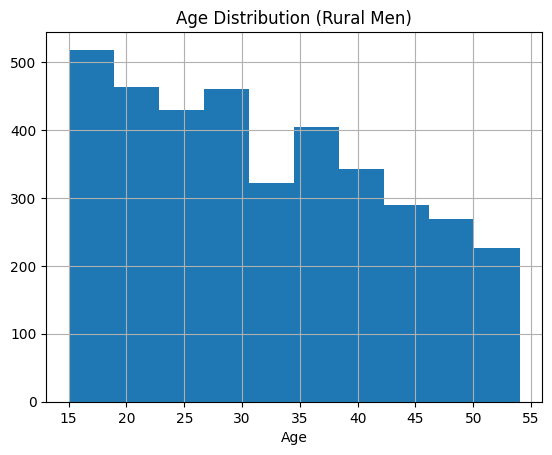

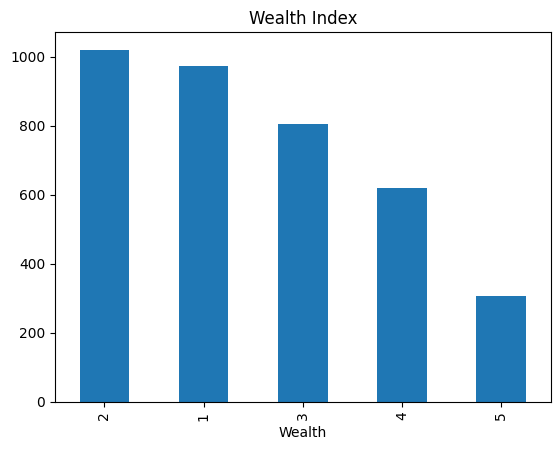

In [5]:
# Age Distribution
df['Age'].hist()
plt.title("Age Distribution (Rural Men)")
plt.xlabel("Age")
plt.show()

# Wealth Distribution
df['Wealth'].value_counts().plot(kind='bar')
plt.title("Wealth Index")
plt.show()